# Airbnb 2019 – Portfolio Allocation Strategy Study

Objective:
Identify high-value listing segments and bottom-quartile segments to recommend a 15% portfolio reallocation strategy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("/Users/joshua.bowditch/Desktop/Springboard DAC/Capstone 2/AB_NYC_2019_RAW.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## Data Cleansing

In [8]:
## -- Handle Missing Values
df = df.dropna(subset=['price'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
## -- Remove Extreme Price Outliers
df = df[df['price'] < df['price'].quantile(0.99)]

In [12]:
## --  Create Segment Variable
df['segment'] = df['neighbourhood_group'] + " - " + df['room_type']

## Issue 1: High-Value Segments

### 1.1 Price Premium Qualification

In [14]:
## -- Calculate City Median
city_median = df['price'].median()

## -- Segment Median
segment_price = df.groupby('segment')['price'].median().reset_index()
segment_price['premium_pct'] = (segment_price['price'] - city_median) / city_median

## -- Filter ≥ 30%
high_price_segments = segment_price[segment_price['premium_pct'] >= 0.30]

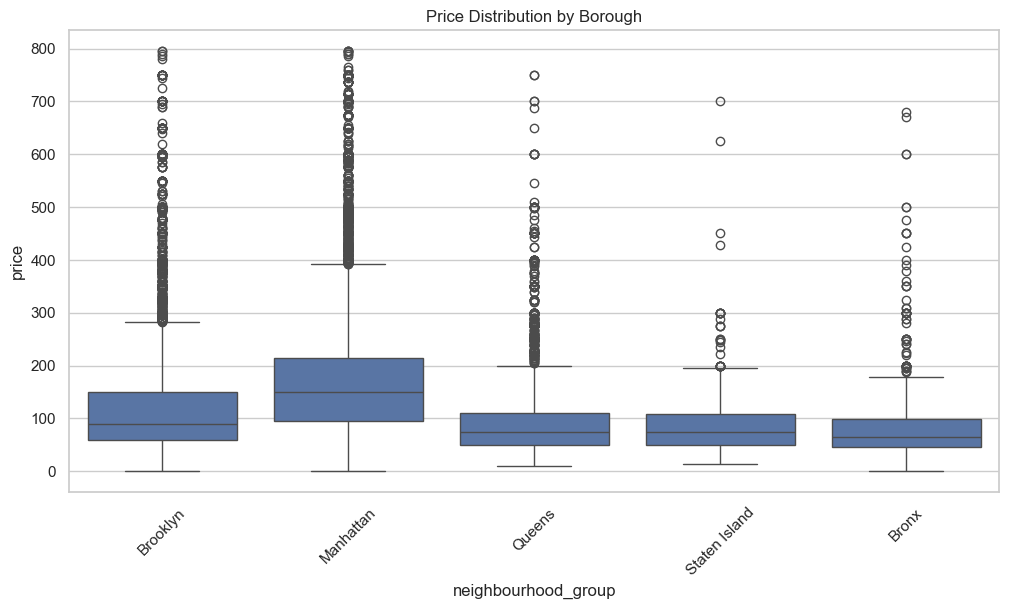

In [15]:
## -- Visualization
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.xticks(rotation=45)
plt.title("Price Distribution by Borough")
plt.show()

### Borough-Level Price Distribution Insights (above)

Borough differences exist, but segmentation by room type reveals stronger structural drivers. Manhattan exhibits the highest median price and the widest price dispersion, indicating both strong pricing power and the presence of premium outliers. Brooklyn follows with moderately high median pricing and significant variability.

Queens, Staten Island, and the Bronx display lower median prices and tighter interquartile ranges, suggesting more constrained pricing power relative to Manhattan and Brooklyn.

However, while borough differences are evident, the overlap in price distributions suggests that geography alone does not fully explain performance variation. Further segmentation by room type is necessary to isolate structural drivers of pricing and engagement performance.

### 1.2 Above-Average Engagement

In [20]:
## -- Filter segments where:
	## price premium ≥ 30%
	## engagement > city average

city_engagement = df['reviews_per_month'].mean()
segment_engagement = df.groupby('segment')['reviews_per_month'].mean().reset_index()

### 1.3 Segment Materiality

In [21]:
## -- Assess % of portfolio
segment_size = df['segment'].value_counts(normalize=True)

### 1.4 Sustainability Risk

In [24]:
## -- Check:
   ## availability_365 mean by segment
   ## host concentration

host_concentration = df.groupby('segment')['calculated_host_listings_count'].mean()

## Issue 2: Low-Yield Segments

### 2.1 Bottom-Quartile Pricing

In [26]:
## -- Identify segments where median price ≤ Q25
price_q25 = df['price'].quantile(0.25)

### 2.2 Bottom-Quartile Engagement

In [27]:
## -- Identify segments where engagement ≤ Q25
engagement_q25 = df['reviews_per_month'].quantile(0.25)

### 2.3 Oversupply Indicators

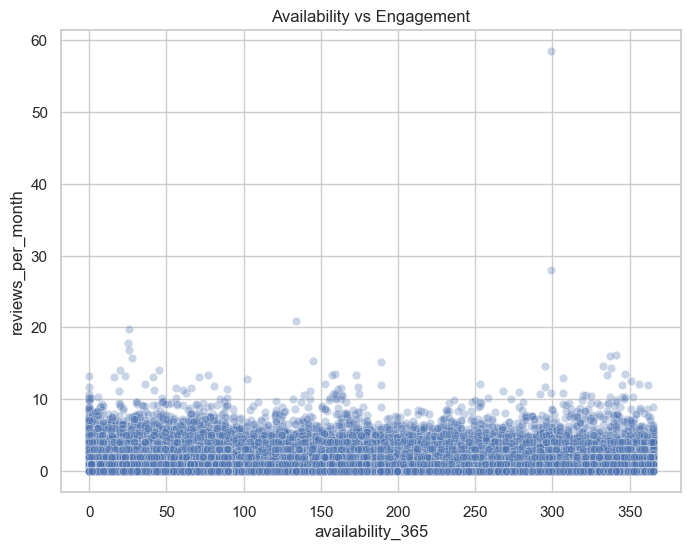

In [41]:
## -- Look at:
	##	High availability
	##	Low engagement

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='availability_365', y='reviews_per_month', alpha=0.3)
plt.title("Availability vs Engagement")
plt.show()

### Scatterplot Insight (above): 
Listings that are available more days per year tend to have slightly higher engagement.

In [38]:
df[['availability_365','reviews_per_month']].corr(method='spearman')

,availability_365,reviews_per_month
availability_365,1.00000,0.30267
reviews_per_month,0.30267,1.00000


### Spearman Correllation Insight (above): 
Availability and engagement exhibit a weak positive correlation (Spearman ≈ 0.30).  
While higher availability does not strongly suppress engagement, it is not a primary driver of structural segment performance.  
Therefore, portfolio decisions focus on segment-level pricing power and engagement rather than availability alone.

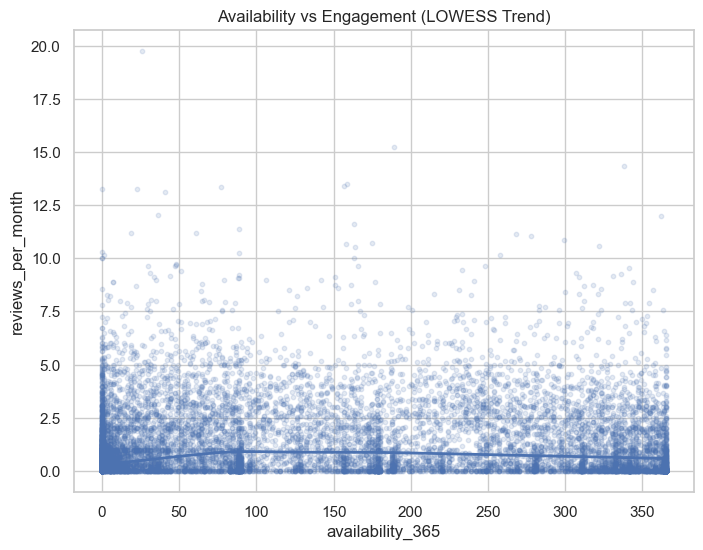

In [40]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=df.sample(min(15000, len(df)), random_state=42),
    x='availability_365', y='reviews_per_month',
    scatter_kws={'alpha':0.15, 's':10},
    lowess=True,
    line_kws={'linewidth':2}
)
plt.title("Availability vs Engagement (LOWESS Trend)")
plt.show()

### 2.4 Persistent Underperformance

In this section, we identify listing segments that fall in the bottom quartile for both median price and engagement (reviews_per_month).

We then evaluate whether:
1. Underperformance is consistent (not driven by a few extreme values).
2. The segment represents a meaningful portion of the overall portfolio.

In [42]:
## -- Calculate Bottom Quartile Thresholds
# Segment-level thresholds
price_q25_seg = segment_summary['median_price'].quantile(0.25)
engagement_q25_seg = segment_summary['median_engagement'].quantile(0.25)

price_q25_seg, engagement_q25_seg

(np.float64(45.0), np.float64(0.355))

In [43]:
## -- Segment-Level Medians
segment_summary = df.groupby('segment').agg(
    median_price=('price', 'median'),
    median_engagement=('reviews_per_month', 'median'),
    listing_count=('segment', 'count')
).reset_index()

In [67]:
## -- Flag Persistent Underperformers
persistent_low_quartile_view = persistent_low[
    ['segment','median_price','median_engagement','listing_count']
].copy()

persistent_low_quartile_view

,segment,median_price,median_engagement,listing_count
5,Brooklyn - Shared room,36.0,0.26,413
14,Staten Island - Shared room,30.0,0.06,9


In [71]:
## -- Portfolio Share (Materiality Check)
persistent_low_materiality_view = persistent_low[
    ['segment','median_price','median_engagement','listing_count','portfolio_share_pct']
].copy().sort_values('portfolio_share_pct', ascending=False)

persistent_low_materiality_view

,segment,median_price,median_engagement,listing_count,portfolio_share_pct
5,Brooklyn - Shared room,36.0,0.26,413,0.853253
14,Staten Island - Shared room,30.0,0.06,9,0.018594


### Segmentation Insight (above): 
Only Brooklyn – Shared Room represents structurally low-performing and materially relevant inventory.

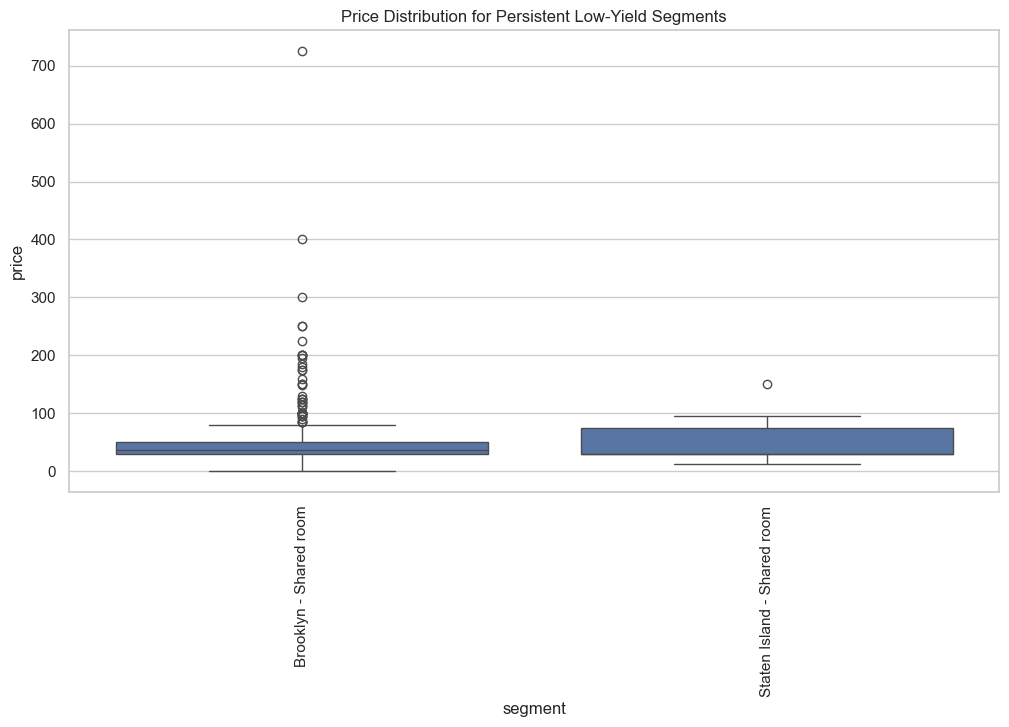

In [72]:
## -- Visualization Check

plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['segment'].isin(persistent_low['segment'])],
            x='segment',
            y='price')
plt.xticks(rotation=90)
plt.title("Price Distribution for Persistent Low-Yield Segments")
plt.show()

### Analysis Pivot - Defining new Low-Yield Identification Logic
The initial requirement of "Bottom quartile price AND bottom quartile engagement" was too narrow resulting in identifying only 1 "under-performing" segment. Therefore I'll define new Low-Yield Identification Logic that will:

1. Standardize segment-level performance
2. Create a composite performance score
3. Rank segments
4. Select bottom 2 subject to materiality threshold

In [51]:
## -- Standardize Performance
from scipy.stats import zscore

segment_summary['price_z'] = zscore(segment_summary['median_price'])
segment_summary['engagement_z'] = zscore(segment_summary['median_engagement'])

# Lower values = worse performance
segment_summary['composite_score'] = (
    segment_summary['price_z'] + segment_summary['engagement_z']
)

In [52]:
## -- Add Materiality Filter

segment_summary['portfolio_share_pct'] = (
    segment_summary['listing_count'] / len(df) * 100
)

material_segments = segment_summary[
    segment_summary['portfolio_share_pct'] >= 0.5
].copy()

In [53]:
## -- Rank and Select Bottom 2

low_yield_segments = (
    material_segments
    .sort_values('composite_score')
    .head(2)
)

low_yield_segments

,segment,median_price,median_engagement,listing_count,price_z,engagement_z,composite_score,portfolio_share_pct
5,Brooklyn - Shared room,36.0,0.26,413,-0.976768,-1.011079,-1.987847,0.853253
4,Brooklyn - Private room,65.0,0.33,10107,-0.318018,-0.818405,-1.136423,20.880937


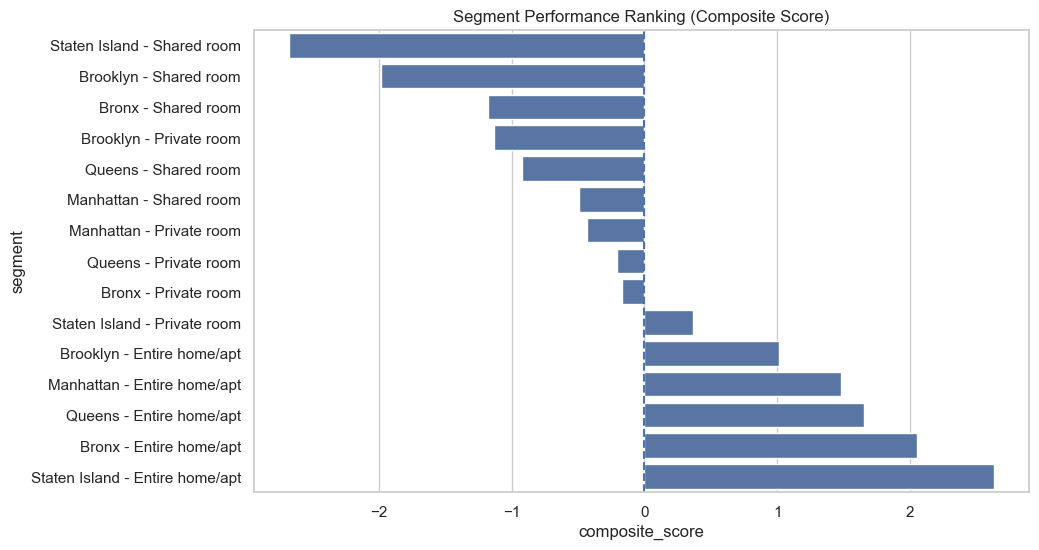

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=segment_summary.sort_values('composite_score'),
    x='composite_score',
    y='segment'
)
plt.title("Segment Performance Ranking (Composite Score)")
plt.axvline(0, linestyle='--')
plt.show()

### Segment Performance Ranking Insight (above):
The data indicates a clear structural performance gradient by room type. Entire home/apartment listings consistently outperform shared and private rooms across boroughs when evaluating both pricing power and engagement. Shared room segments, in particular, underperform 
systematically.

#### Conclusions
- Room type is a stronger driver of performance than borough.
- Demand preference likely favors privacy.
- The shared-room product may be structurally disadvantaged in NYC.

In [55]:
room_type_summary = segment_summary.groupby(
    segment_summary['segment'].str.split(' - ').str[1]
).agg(
    avg_composite_score=('composite_score','mean'),
    avg_price=('median_price','mean'),
    avg_engagement=('median_engagement','mean')
).reset_index()

room_type_summary.sort_values('avg_composite_score')

,segment,avg_composite_score,avg_price,avg_engagement
2,Shared room,-1.451615,42.4,0.402
1,Private room,-0.314955,63.6,0.640
0,Entire home/apt,1.766570,131.0,0.840


## Insights

- Availability and engagement show weak positive correlation (~0.30)
- Structural underperformance is rare at segment level
- Shared rooms are consistently weak across boroughs
- Staten Island segments are immaterial in portfolio size
- Brooklyn Shared Rooms represent ~0.85% of listings and underperform structurally

## Raw Insights

In [56]:
## -- Filter Entire Home/Apt Only
entire_segments = segment_summary[
    segment_summary['segment'].str.contains('Entire home/apt')
].sort_values('composite_score', ascending=False)

entire_segments

,segment,median_price,median_engagement,listing_count,price_z,engagement_z,composite_score,portfolio_share_pct
12,Staten Island - Entire home/apt,100.0,1.41,172,0.477026,2.154277,2.631304,0.355350
0,Bronx - Entire home/apt,100.0,1.20,378,0.477026,1.576256,2.053282,0.780943
9,Queens - Entire home/apt,120.0,0.89,2087,0.931337,0.722986,1.654323,4.311716
6,Manhattan - Entire home/apt,190.0,0.25,12895,2.521425,-1.038604,1.482821,26.640911
3,Brooklyn - Entire home/apt,145.0,0.45,9481,1.499226,-0.488107,1.011119,19.587629


In [57]:
## -- Filter Shared Room Only
shared_segments = segment_summary[
    segment_summary['segment'].str.contains('Shared room')
].sort_values('composite_score')

shared_segments

,segment,median_price,median_engagement,listing_count,price_z,engagement_z,composite_score,portfolio_share_pct
14,Staten Island - Shared room,30.0,0.06,9,-1.113062,-1.561576,-2.674637,0.018594
5,Brooklyn - Shared room,36.0,0.26,413,-0.976768,-1.011079,-1.987847,0.853253
2,Bronx - Shared room,40.0,0.52,59,-0.885906,-0.295433,-1.181339,0.121893
11,Queens - Shared room,37.0,0.64,195,-0.954053,0.034865,-0.919188,0.402868
8,Manhattan - Shared room,69.0,0.53,477,-0.227155,-0.267908,-0.495064,0.985476


In [58]:
## --  Add Materiality Constraint - Segment: Invest/Prioritize
entire_segments = entire_segments[
    entire_segments['portfolio_share_pct'] >= 1
]

In [59]:
## --  Add Materiality Constraint - Segment: Divest/Deprioritize
shared_segments = shared_segments[
    shared_segments['portfolio_share_pct'] >= 0.5
]

In [60]:
entire_segments[['segment','composite_score','portfolio_share_pct']]

,segment,composite_score,portfolio_share_pct
9,Queens - Entire home/apt,1.654323,4.311716
6,Manhattan - Entire home/apt,1.482821,26.640911
3,Brooklyn - Entire home/apt,1.011119,19.587629


In [61]:
shared_segments[['segment','composite_score','portfolio_share_pct']]

,segment,composite_score,portfolio_share_pct
5,Brooklyn - Shared room,-1.987847,0.853253
8,Manhattan - Shared room,-0.495064,0.985476


## Final Insights

This analysis identified clear structural differences in performance across Airbnb listing segments when evaluating both median price and engagement.

1. Room type is the primary driver of performance. Entire home/apt listings consistently outperform shared and private rooms across boroughs in both pricing power and engagement. Shared room segments underperform structurally.

2. Borough refines performance within room types. Among Entire home/apt listings, Queens, Manhattan, and Brooklyn show the strongest composite performance. Queens – Entire home/apt demonstrates the highest relative performance while representing a smaller share of the total portfolio, indicating potential opportunity.

3. Shared room segments represent the weakest materially relevant inventory. Brooklyn – Shared room and Manhattan – Shared room both exhibit negative composite scores and limited pricing power relative to the broader market.

### Portfolio Reallocation Recommendation

To support a ~15% portfolio reallocation strategy:

- Reduce emphasis on shared room inventory in Brooklyn and Manhattan.
- Increase allocation toward Entire home/apt segments, particularly in Queens where performance materially exceeds current portfolio representation.
- Maintain selective exposure to Private rooms where performance is near neutral, but avoid aggressive expansion.

Overall, the data suggests that product mix (room type) is a stronger structural driver of performance than geography alone. Portfolio strategy should prioritize privacy-oriented listings while using borough-level performance to refine allocation decisions.